# Car Price Prediction using Linear Regression

This project aims to develop a machine learning model that predicts the selling price of a used car based on various features such as the manufacturing year, present price, kilometers driven, fuel type, transmission, and ownership history. The Linear Regression algorithm is used to learn the relationship between these features and the selling price. The trained model will later be integrated into a Flask web application, allowing users to enter car details and receive an estimated selling price through a simple web interface.



## Project Objectives

Understand the structure of the car price dataset. Perform data cleaning and preprocessing. Analyze the dataset using visualization techniques. Build a Linear Regression model for price prediction. Evaluate model performance using regression metrics. Save the trained model for deployment. Integrate the model with a Flask web application

##  Import Required Libraries

- **pandas** - load and work with tabular data
- **numpy** - numerical operations
- **matplotlib / seaborn** - visualize data
- **scikit-learn** - machine learning model, train/test split, and evaluation metrics
- **pickle**  - save the trained model to a file

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle


##  Load Dataset


In [2]:

cars_data = pd.read_csv("data/Cardetails.csv")


###  Dataset

 The head() function displays the first five rows of the dataset,  the data has been loaded correctly and to understand the available features.

In [3]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0




Before cleaning or modeling, we check the size, column names, data types, and basic statistics of the dataset.

In [4]:
print("Shape of dataset:", cars_data.shape)
print("\nColumn names:")
print(cars_data.columns.tolist())


Shape of dataset: (8128, 13)

Column names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


In [5]:
cars_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [6]:
cars_data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


##  Data Cleaning

###  Drop Columns We Won't Use

`torque`  and `seats` is mostly constant/not very informative here, so we drop both.

In [7]:
cars_data.drop(columns=["torque", "seats"], inplace=True)
cars_data.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp


### 4.2 Check for Missing Values

In [8]:
cars_data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
dtype: int64

### 4.3 Check and Remove Duplicate Rows

Duplicate rows can bias the model, so we remove them.

In [9]:
print("Duplicate rows before:", cars_data.duplicated().sum())

cars_data.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", cars_data.shape)


Duplicate rows before: 1202
Shape after removing duplicates: (6926, 11)


## 5. Data Preprocessing

Some columns contain both numbers and text units (e.g. `"23.4 kmpl"`, `"1248 CC"`). We need to strip the units and convert these columns to numeric values before they can be used in the model.

In [10]:
# Remove text units from these columns
cars_data["mileage"] = cars_data["mileage"].astype(str).str.replace(" kmpl", "", regex=False)
cars_data["mileage"] = cars_data["mileage"].astype(str).str.replace(" km/kg", "", regex=False)

cars_data["engine"] = cars_data["engine"].astype(str).str.replace(" CC", "", regex=False)

cars_data["max_power"] = cars_data["max_power"].astype(str).str.replace(" bhp", "", regex=False)


In [11]:
# Convert cleaned columns to numeric
# errors="coerce" turns any invalid/empty values into NaN instead of crashing

cars_data["mileage"] = pd.to_numeric(cars_data["mileage"], errors="coerce")
cars_data["engine"] = pd.to_numeric(cars_data["engine"], errors="coerce")
cars_data["max_power"] = pd.to_numeric(cars_data["max_power"], errors="coerce")

cars_data.info()


<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   str    
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   str    
 5   seller_type    6926 non-null   str    
 6   transmission   6926 non-null   str    
 7   owner          6926 non-null   str    
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6720 non-null   float64
dtypes: float64(3), int64(3), str(5)
memory usage: 649.3 KB


Converting to numeric create a few missing values (e.g. blank entries become `NaN`). Since this is a small number of rows compared to the full dataset, i simply drop them.

In [12]:
cars_data.dropna(inplace=True)

print("Missing values after cleaning:")
print(cars_data.isnull().sum())
print("\nShape after cleaning:", cars_data.shape)


Missing values after cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
dtype: int64

Shape after cleaning: (6717, 11)


## 6. Feature

 creating new, more useful columns from existing raw columns.

**6.1 Brand** — The `name` column contains the full car name (e.g. `"Maruti Swift Dzire VDI"`), which has too many unique values to be useful directly. We extract just the **brand** (first word), which is a much more informative and manageable feature.

**6.2 Car Age** — Instead of using the raw manufacturing `year`, we convert it into `car_age` how many years old the car is. 

In [13]:
# Extract brand name from the full car name
cars_data["brand"] = cars_data["name"].apply(lambda x: x.split()[0])

# Create car_age feature 
cars_data["car_age"] = 2026 - cars_data["year"]

cars_data[["name", "brand", "year", "car_age"]].head()


,name,brand,year,car_age
0,Maruti Swift Dzire VDI,Maruti,2014,12
1,Skoda Rapid 1.5 TDI Ambition,Skoda,2014,12
2,Honda City 2017-2020 EXi,Honda,2006,20
3,Hyundai i20 Sportz Diesel,Hyundai,2010,16
4,Maruti Swift VXI BSIII,Maruti,2007,19


Now that we have `brand` and `car_age`, the original `name` and `year` columns are no longer needed, so we drop them to avoid duplicate information.

In [14]:
cars_data.drop(columns=["name", "year"], inplace=True)
cars_data.head()


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,Maruti,12
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,Skoda,12
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,Honda,20
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,Hyundai,16
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,Maruti,19


##  7. Exploratory Data Analysis (EDA)

e visualize the data to understand patterns and relationships.

### Distribution of Selling Price

The selling price is our target variable. Visualizing its distribution shows how prices are spread across the dataset.

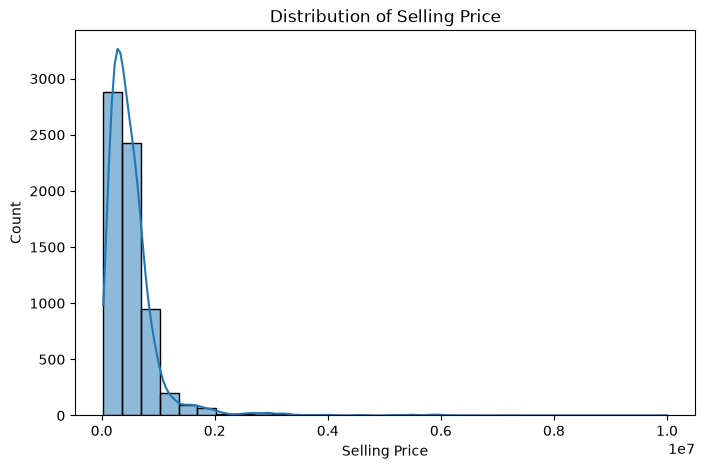

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(cars_data["selling_price"], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()


### Fuel Type Distribution

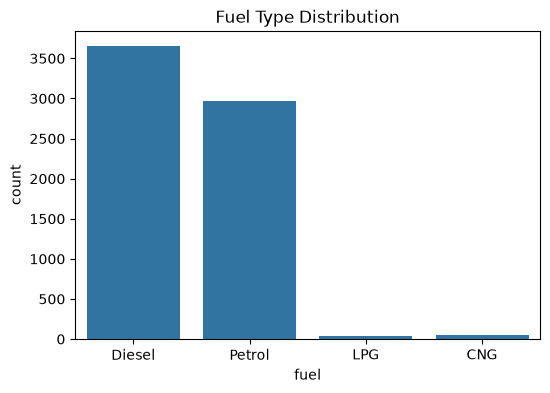

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="fuel", data=cars_data)
plt.title("Fuel Type Distribution")
plt.show()


### Transmission Type Distribution

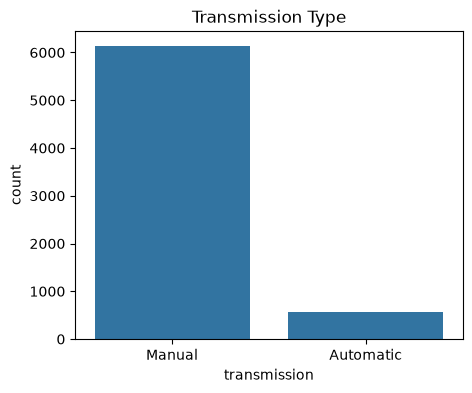

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x="transmission", data=cars_data)
plt.title("Transmission Type")
plt.show()


### Selling Price vs Car Age

Older cars are generally expected to sell for less.

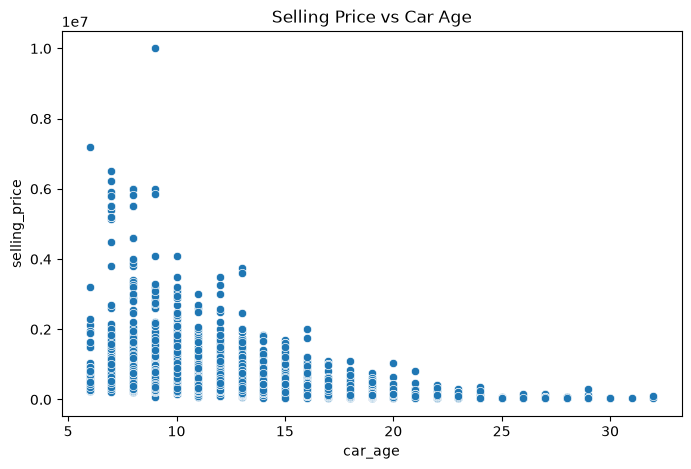

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="car_age", y="selling_price", data=cars_data)
plt.title("Selling Price vs Car Age")
plt.show()


### Selling Price vs Kilometers Driven

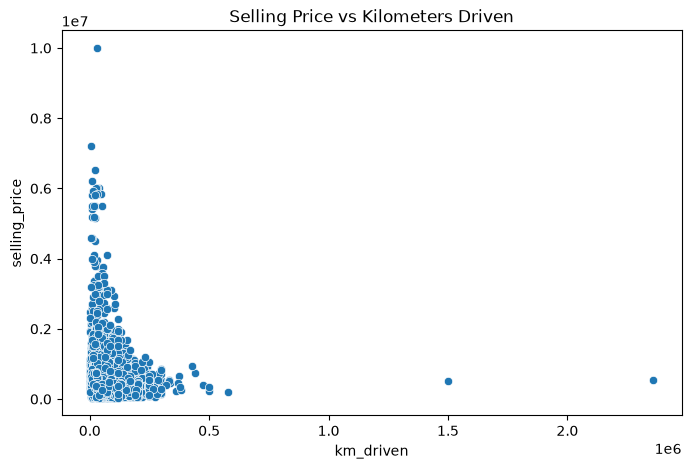

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="km_driven", y="selling_price", data=cars_data)
plt.title("Selling Price vs Kilometers Driven")
plt.show()


## 8. Encode Categorical Columns

Linear Regression only works with numbers, but our dataset still has text categorical columns: `brand`, `fuel`, `seller_type`, `transmission`, and `owner`. We use **LabelEncoder** to convert each category into a number.

We keep the fitted encoders in a dictionary so the *same* encoding can be reused later when predicting on new data.

In [20]:
cars_data.select_dtypes(include="object").columns

C:\Users\acer\AppData\Local\Temp\ipykernel_75296\1053603485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cars_data.select_dtypes(include="object").columns


Index(['fuel', 'seller_type', 'transmission', 'owner', 'brand'], dtype='str')

In [21]:
categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]

encoders = {}  # store one encoder per column, so we can reuse it later

for col in categorical_cols:
    le = LabelEncoder()
    cars_data[col] = le.fit_transform(cars_data[col])
    encoders[col] = le

cars_data.head()


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,450000,145500,1,1,1,0,23.40,1248.0,74.00,20,12
1,370000,120000,1,1,1,2,21.14,1498.0,103.52,26,12
2,158000,140000,3,1,1,4,17.70,1497.0,78.00,10,20
3,225000,127000,1,1,1,0,23.00,1396.0,90.00,11,16
4,130000,120000,3,1,1,0,16.10,1298.0,88.20,20,19


In [22]:
cars_data.info()

<class 'pandas.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   selling_price  6717 non-null   int64  
 1   km_driven      6717 non-null   int64  
 2   fuel           6717 non-null   int64  
 3   seller_type    6717 non-null   int64  
 4   transmission   6717 non-null   int64  
 5   owner          6717 non-null   int64  
 6   mileage        6717 non-null   float64
 7   engine         6717 non-null   float64
 8   max_power      6717 non-null   float64
 9   brand          6717 non-null   int64  
 10  car_age        6717 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 629.7 KB


## 9. Prepare Data for Model Training

We separate the dataset into:
- **X (input features)** — everything except `selling_price`
- **y (target)** — the `selling_price` column, which is what we want to predict

In [23]:
X = cars_data.drop("selling_price", axis=1)
y = cars_data["selling_price"]

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


Input Shape : (6717, 10)
Target Shape: (6717,)


In [24]:
X.head()

,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,145500,1,1,1,0,23.40,1248.0,74.00,20,12
1,120000,1,1,1,2,21.14,1498.0,103.52,26,12
2,140000,3,1,1,4,17.70,1497.0,78.00,10,20
3,127000,1,1,1,0,23.00,1396.0,90.00,11,16
4,120000,3,1,1,0,16.10,1298.0,88.20,20,19


## 10. Split the Dataset

We split the data into a **training set** (used to teach the model) and a **testing set** (used to check how well it learned, on data it hasn't seen before). We use an 80/20 split.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)


Training Features: (5373, 10)
Testing Features : (1344, 10)
Training Labels  : (5373,)
Testing Labels   : (1344,)


##  11: Train the Linear Regression Model

Linear Regression tries to find the best straight-line relationship between the input features and the selling price.

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


### Model Coefficients

Each feature gets a coefficient (weight):
- A **positive** coefficient means that feature increases predicted price.
- A **negative** coefficient means that feature decreases predicted price.

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients


,Feature,Coefficient
0,km_driven,-0.615739
1,fuel,-28940.488372
2,seller_type,-118263.074009
3,transmission,-336672.663490
4,owner,-13996.062078
5,mileage,3805.602929
6,engine,56.277917
7,max_power,8683.446972
8,brand,1381.567839
9,car_age,-34678.599223


### Intercept

The intercept is the baseline predicted price when all feature values are zero:

`Selling Price = (Feature1 × Coefficient1) + (Feature2 × Coefficient2) + ... + Intercept`

In [28]:
print("Intercept:", model.intercept_)

Intercept: 543932.7939885249


## 12. Evaluate the Model

The trained model to predict prices on the **test set** (data it has not seen), then compare the predictions to the actual prices using three common metrics:

- **R² Score** — how much of the variation in price the model explains (closer to 1 is better).
- **MAE (Mean Absolute Error)** — average size of the prediction error, in the same units as price.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes larger errors more.

In [29]:
y_pred = model.predict(X_test)

### Actual vs Predicted Prices (sample)

In [30]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": np.round(y_pred, 2)
})

results.head(10)


,Actual Price,Predicted Price
0,450000,1515635.83
1,800000,697305.89
2,75000,237028.55
3,3200000,1848583.40
4,1650000,1494333.84
5,180000,17481.55
6,1019999,663766.76
7,350000,356698.99
8,722000,544127.48
9,315000,209691.14


In [31]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance")
print("-" * 30)
print("R2 Score:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))


Model Performance
------------------------------
R2 Score: 0.6594
Mean Absolute Error: 168417.9
Root Mean Squared Error: 273376.79


### Visualize Actual vs Predicted Prices

If the model performs well, the points should fall close to the red diagonal line (which represents a perfect prediction).

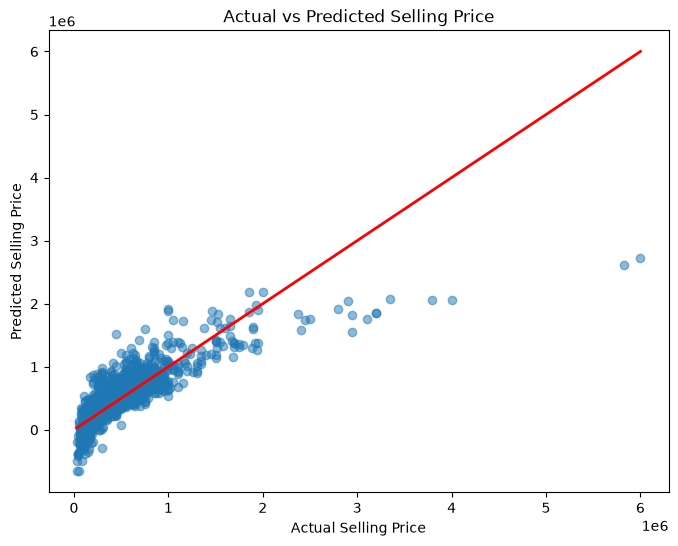

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()


##  13: Test the Model on a New Sample

Now we test the model with one made-up car to see how prediction works in practice.

Because the model was trained on **encoded** brand/fuel/seller_type/transmission/owner values, any new sample must be encoded the exact same way using the encoders we saved in Step 8.

In [33]:
print(X.columns.tolist())


['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'brand', 'car_age']


In [34]:
# Describe a new car in plain, human-readable terms
new_car = {
    "brand": "Maruti",
    "km_driven": 50000,
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
    "owner": "First Owner",
    "mileage": 22.5,
    "engine": 1248,
    "max_power": 74.0,
    "car_age": 6
}

# Encode the text fields using the SAME encoders fitted on the training data
encoded_car = new_car.copy()
for col in categorical_cols:
    encoded_car[col] = encoders[col].transform([new_car[col]])[0]

# Arrange the values in the same column order the model was trained on
sample_car = pd.DataFrame([encoded_car])[X.columns]
sample_car


,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,50000,3,1,1,0,22.5,1248,74.0,20,6


In [35]:
predicted_price = model.predict(sample_car)
print("Predicted Selling Price: Rs.", round(predicted_price[0], 2))


Predicted Selling Price: Rs. 589384.36


We can also test the model on a real row taken directly from the test set, and compare the prediction to the actual known price.

In [36]:
sample = X_test.iloc[[0]]
actual_price = y_test.iloc[0]
predicted_price = model.predict(sample)

print("Actual Price    : Rs.", actual_price)
print("Predicted Price : Rs.", round(predicted_price[0], 2))


Actual Price    : Rs. 450000
Predicted Price : Rs. 1515635.83


## 14. Save the Model

We save the trained model and the label encoders together, since both are needed to make predictions on new, raw (non-encoded) data later — for example, inside a Flask web app.

In [37]:
with open("car_price_model.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "encoders": encoders,
        "feature_order": X.columns.tolist()
    }, f)

print("Model saved as car_price_model.pkl")


Model saved as car_price_model.pkl


## Conclusion

We built a simple Linear Regression model to predict used car selling prices:

1. Loaded and cleaned the raw dataset.
2. Engineered two new features (`brand`, `car_age`) from raw columns.
3. Encoded categorical columns into numbers.
4. Trained a Linear Regression model and evaluated it with R², MAE, and RMSE.
5. Tested the model on a new, hand-made sample car.
6. Saved the model (with its encoders) for later use in a web app.

